# Shift-Guard — Random Forest Baseline

**Goal:** Train and honestly evaluate a first model that classifies 30-second
windows of wrist-sensor data as **calm (0)** or **stressed (1)**, using the
features extracted in `EDA.ipynb` / `extract_features.py` (`features_30s.csv`).

**Why Random Forest as the baseline:**
- Works well on tabular features with no scaling required
- Handles non-linear interactions between signals automatically
- Gives feature importances out of the box — tells us which signals matter
- Fast to train; a sensible bar that any fancier model (LSTM, gradient boosting) must beat

**The single most important design choice — Leave-One-Subject-Out (LOSO):**
A burnout device is worn by people it was *never trained on*. So we evaluate with
**Leave-One-Subject-Out cross-validation**: train on 14 subjects, test on the 1
held-out subject, repeat 15 times. This is the only honest estimate of real-world
performance. (We also show the naive random-split number to demonstrate how badly
it *overstates* accuracy by leaking each person into both train and test.)

**Evaluation suite in this notebook:**
1. Aggregate metrics (accuracy, precision, recall, F1, ROC-AUC) on out-of-fold predictions
2. Per-subject (per-fold) metrics — does it generalise to *everyone*?
3. Confusion matrix
4. ROC curve
5. Feature importances
6. Honest (LOSO) vs leaky (random split) vs majority-class baseline comparison

In [26]:
# ─── Imports & data loading ───────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# This notebook lives in notebooks/. Anchor to the project root so relative paths
# (outputs/, data/) resolve regardless of where Jupyter is launched from.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve,
)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
RANDOM_STATE = 42

# The modeling dataset built by extract_features.py (30s windows, 50% overlap).
df = pd.read_csv('outputs/features_30s.csv')
print(f'Loaded outputs/features_30s.csv → {df.shape[0]} windows × {df.shape[1]} columns')
df.head()

Loaded features_30s.csv → 1780 windows × 21 columns


,subject,window_start_s,label,acc_mag_mean,acc_mag_std,acc_hf_mean,bvp_mean,bvp_std,hr_mean,hr_std,...,hr_min,hr_max,temp_mean,temp_slope,temp_delta,eda_mean,eda_std,eda_slope,eda_min,eda_max
0,2,315,0,64.034564,8.115288,5.136214,2.047870,125.133789,100.569405,8.802968,...,83.794624,116.093320,35.819667,0.000083,0.02,1.279663,0.133281,-0.002594,1.037032,1.497030
1,2,330,0,64.087476,7.167749,4.197735,-0.931635,129.351807,101.751826,8.114961,...,84.404224,116.093320,35.802000,-0.000576,-0.06,1.209851,0.093624,-0.000175,1.037032,1.436807
2,2,345,0,63.233402,2.085265,1.219992,-2.026083,84.482491,91.167707,12.840800,...,68.792000,107.636111,35.760000,-0.000708,-0.06,1.164514,0.079703,-0.002088,1.013968,1.316362
3,2,360,0,63.170467,2.709638,1.272838,0.889818,50.219208,85.511332,13.154806,...,68.420214,107.132546,35.716000,-0.000700,-0.04,1.015014,0.109211,-0.003112,0.831920,1.198480
4,2,375,0,63.377840,3.019637,1.581064,-0.349969,51.908495,89.084869,9.191453,...,68.420214,103.040863,35.694667,-0.000036,-0.03,0.862839,0.072732,-0.001991,0.757603,1.012687


=== CLASS BALANCE ===
calm (0)     : 1143
stressed (1) : 637
ratio (s/c)  : 0.557  (moderately imbalanced → use class_weight="balanced")
subjects     : 15


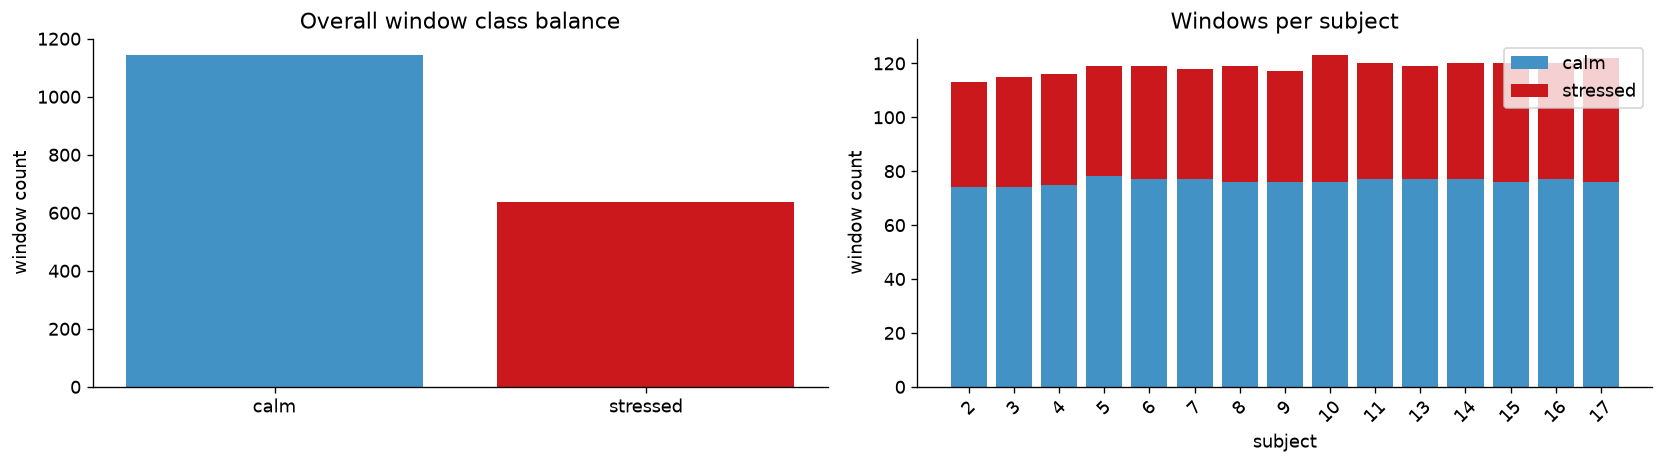

In [27]:
# ─── Data overview: class balance + per-subject window counts ─────────────────
# Confirm the data matches what the EDA reported before we trust any model on it.

n_calm     = int((df['label'] == 0).sum())
n_stressed = int((df['label'] == 1).sum())
print('=== CLASS BALANCE ===')
print(f'calm (0)     : {n_calm}')
print(f'stressed (1) : {n_stressed}')
print(f'ratio (s/c)  : {n_stressed / n_calm:.3f}  '
      f'(moderately imbalanced → use class_weight="balanced")')
print(f'subjects     : {df["subject"].nunique()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: overall class balance
axes[0].bar(['calm', 'stressed'], [n_calm, n_stressed], color=['#4292c6', '#cb181d'])
axes[0].set_title('Overall window class balance')
axes[0].set_ylabel('window count')

# Right: per-subject stacked calm/stressed counts
pivot = df.pivot_table(index='subject', columns='label', values='window_start_s',
                       aggfunc='count', fill_value=0)
pivot = pivot.loc[sorted(pivot.index)]
axes[1].bar(pivot.index.astype(str), pivot[0], label='calm',     color='#4292c6')
axes[1].bar(pivot.index.astype(str), pivot[1], bottom=pivot[0],  label='stressed', color='#cb181d')
axes[1].set_title('Windows per subject')
axes[1].set_xlabel('subject'); axes[1].set_ylabel('window count'); axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## Preprocessing — per-subject normalization

People have very different baseline physiology (resting HR of 55 vs 85 BPM, etc.).
As the EDA's Section 8 showed, those between-person differences can be larger than
the stress response itself. So we **z-score each subject's features using only that
subject's own windows** — after this, every feature means "how far above/below
*this person's* normal."

This is leakage-safe (each subject is normalized independently of all others) and
mirrors real deployment, where a device calibrates to its individual wearer.

`subject` and `window_start_s` are identifiers, not features, so they're excluded
from `X`. `subject` is kept separately as the **group** for Leave-One-Subject-Out CV.

In [28]:
# ─── Build X (features), y (label), groups (subject) ──────────────────────────
ID_COLS      = ['subject', 'window_start_s', 'label']
FEATURE_COLS = [c for c in df.columns if c not in ID_COLS]

y      = df['label'].values
groups = df['subject'].values

# Per-subject z-score: subtract each subject's mean, divide by their std.
df_norm = df.copy()
df_norm[FEATURE_COLS] = (
    df.groupby('subject')[FEATURE_COLS]
      .transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-8))
)
X = df_norm[FEATURE_COLS].values

print(f'X shape : {X.shape}   ({len(FEATURE_COLS)} features)')
print(f'y shape : {y.shape}   (calm={int((y==0).sum())}, stressed={int((y==1).sum())})')
print(f'groups  : {len(np.unique(groups))} unique subjects')
print(f'\nFeatures used:\n  {FEATURE_COLS}')

X shape : (1780, 18)   (18 features)
y shape : (1780,)   (calm=1143, stressed=637)
groups  : 15 unique subjects

Features used:
  ['acc_mag_mean', 'acc_mag_std', 'acc_hf_mean', 'bvp_mean', 'bvp_std', 'hr_mean', 'hr_std', 'hr_slope', 'hr_min', 'hr_max', 'temp_mean', 'temp_slope', 'temp_delta', 'eda_mean', 'eda_std', 'eda_slope', 'eda_min', 'eda_max']


## Model + Leave-One-Subject-Out cross-validation

We train one `RandomForestClassifier` per fold (300 trees, `class_weight='balanced'`
to counter the 0.56 imbalance). In each of the 15 folds, one subject is fully held
out for testing. We collect **out-of-fold (OOF) predictions** — every window is
predicted exactly once, by a model that never saw its subject — and also record
each fold's individual metrics so we can see whether the model generalises to
*every* person, not just on average.

In [29]:
# ─── Leave-One-Subject-Out CV ─────────────────────────────────────────────────
def make_rf(**overrides):
    """Factory so every fold uses an identical, fresh Random Forest.

    Pass keyword overrides (e.g. make_rf(max_depth=6)) for the overfitting checks.
    """
    params = dict(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',   # counter the calm-heavy class imbalance
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    params.update(overrides)
    return RandomForestClassifier(**params)

logo     = LeaveOneGroupOut()
oof_pred = np.zeros(len(y), dtype=int)     # out-of-fold hard predictions
oof_prob = np.zeros(len(y), dtype=float)   # out-of-fold P(stressed)
fold_rows = []

for train_idx, test_idx in logo.split(X, y, groups):
    test_sid = int(groups[test_idx][0])

    clf = make_rf()
    clf.fit(X[train_idx], y[train_idx])

    pred = clf.predict(X[test_idx])
    prob = clf.predict_proba(X[test_idx])[:, 1]
    oof_pred[test_idx] = pred
    oof_prob[test_idx] = prob

    # Per-fold metrics (AUC needs both classes present in the held-out subject).
    has_both = len(np.unique(y[test_idx])) > 1
    fold_rows.append({
        'subject':  f'S{test_sid}',
        'n_windows': len(test_idx),
        'accuracy':  accuracy_score(y[test_idx], pred),
        'precision': precision_score(y[test_idx], pred, zero_division=0),
        'recall':    recall_score(y[test_idx], pred, zero_division=0),
        'f1':        f1_score(y[test_idx], pred, zero_division=0),
        'roc_auc':   roc_auc_score(y[test_idx], prob) if has_both else np.nan,
    })

fold_df = pd.DataFrame(fold_rows)
print(f'LOSO complete — {len(fold_df)} folds (one held-out subject each).')

LOSO complete — 15 folds (one held-out subject each).


## Evaluation 1 — Aggregate metrics (out-of-fold)

These metrics are computed across all OOF predictions, so they reflect performance
on subjects the model never trained on. What each one means here:
- **Accuracy** — overall fraction of windows classified correctly
- **Precision** — when it says "stressed", how often is it right (controls false alarms)
- **Recall** — of all truly stressed windows, how many it catches (controls missed stress)
- **F1** — harmonic mean of precision & recall (the headline single number)
- **ROC-AUC** — ranking quality independent of threshold (1.0 = perfect, 0.5 = random)

In [30]:
# ─── Aggregate out-of-fold metrics ────────────────────────────────────────────
metrics = {
    'accuracy':  accuracy_score(y, oof_pred),
    'precision': precision_score(y, oof_pred, zero_division=0),
    'recall':    recall_score(y, oof_pred, zero_division=0),
    'f1':        f1_score(y, oof_pred, zero_division=0),
    'roc_auc':   roc_auc_score(y, oof_prob),
}

print('=== LEAVE-ONE-SUBJECT-OUT — AGGREGATE METRICS (honest) ===')
for name, val in metrics.items():
    print(f'  {name:<10}: {val:.3f}')

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y, oof_pred, target_names=['calm', 'stressed'], digits=3))

=== LEAVE-ONE-SUBJECT-OUT — AGGREGATE METRICS (honest) ===
  accuracy  : 0.905
  precision : 0.874
  recall    : 0.859
  f1        : 0.866
  roc_auc   : 0.970

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        calm      0.922     0.931     0.926      1143
    stressed      0.874     0.859     0.866       637

    accuracy                          0.905      1780
   macro avg      0.898     0.895     0.896      1780
weighted avg      0.905     0.905     0.905      1780



## Evaluation 2 — Per-subject (per-fold) metrics

Averages can hide a model that works great for 14 people and fails for one. This
table and chart show accuracy/F1 for each held-out subject. A low bar means that
person's physiology doesn't match the population the model learned — exactly the
kind of generalisation gap that matters for a wearable.

=== PER-SUBJECT (held-out) METRICS ===
subject  n_windows  accuracy  precision   recall       f1  roc_auc
     S2        113  0.902655   0.804348 0.948718 0.870588 0.972453
     S3        115  0.817391   0.738095 0.756098 0.746988 0.915293
     S4        116  1.000000   1.000000 1.000000 1.000000 1.000000
     S5        119  0.966387   0.911111 1.000000 0.953488 0.999375
     S6        119  0.974790   0.933333 1.000000 0.965517 1.000000
     S7        118  0.974576   0.931818 1.000000 0.964706 0.999683
     S8        119  0.991597   1.000000 0.976744 0.988235 1.000000
     S9        117  1.000000   1.000000 1.000000 1.000000 1.000000
    S10        123  1.000000   1.000000 1.000000 1.000000 1.000000
    S11        120  0.716667   0.628571 0.511628 0.564103 0.824222
    S13        119  1.000000   1.000000 1.000000 1.000000 1.000000
    S14        120  0.866667   0.846154 0.767442 0.804878 0.962247
    S15        120  0.875000   0.853659 0.795455 0.823529 0.968900
    S16        120  1.0

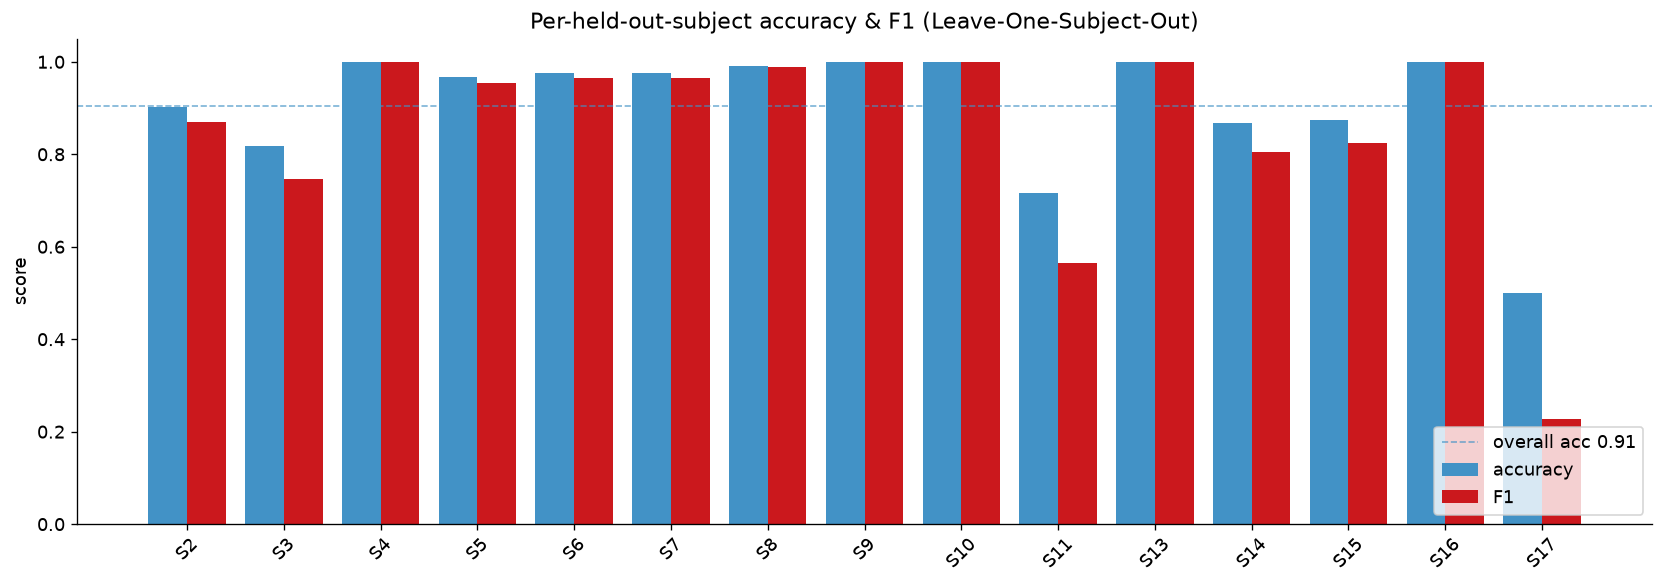

In [31]:
# ─── Per-fold metrics table + chart ───────────────────────────────────────────
print('=== PER-SUBJECT (held-out) METRICS ===')
print(fold_df.to_string(index=False))
print('\nMean ± std across folds:')
for col in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f'  {col:<10}: {fold_df[col].mean():.3f} ± {fold_df[col].std():.3f}')

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(fold_df)); w = 0.4
ax.bar(x - w/2, fold_df['accuracy'], w, label='accuracy', color='#4292c6')
ax.bar(x + w/2, fold_df['f1'],       w, label='F1',       color='#cb181d')
ax.axhline(metrics['accuracy'], color='#4292c6', ls='--', lw=1, alpha=0.7,
           label=f"overall acc {metrics['accuracy']:.2f}")
ax.set_xticks(x); ax.set_xticklabels(fold_df['subject'], rotation=45)
ax.set_ylim(0, 1.05); ax.set_ylabel('score')
ax.set_title('Per-held-out-subject accuracy & F1 (Leave-One-Subject-Out)')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

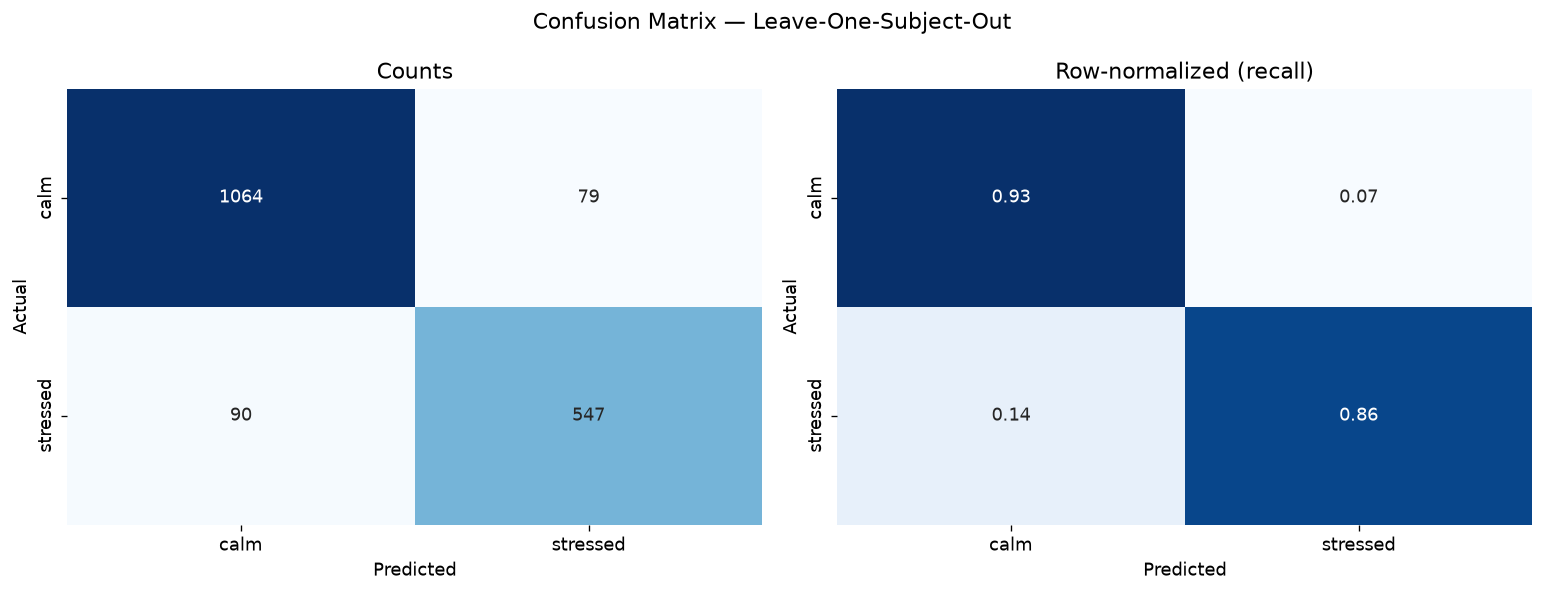

True calm kept calm (TN)      : 1064
Calm flagged as stressed (FP) : 79  ← false alarms
Stress missed as calm (FN)    : 90  ← missed stress (most costly for burnout)
Stress caught (TP)            : 547


In [32]:
# ─── Evaluation 3 — Confusion matrix (out-of-fold) ────────────────────────────
# One clean panel: cell COLOR = row-normalized share (so the large true-calm cell
# doesn't wash out the other three), cell TEXT = raw count + that row's percentage.
cm     = confusion_matrix(y, oof_pred, labels=[0, 1])
cm_row = cm / cm.sum(axis=1, keepdims=True)   # each row sums to 1 (per true class)

annot = np.array([[f'{cm[i, j]}\n({cm_row[i, j] * 100:.1f}%)' for j in range(2)]
                  for i in range(2)])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_row, annot=annot, fmt='', cmap='Blues', vmin=0, vmax=1,
            xticklabels=['calm', 'stressed'], yticklabels=['calm', 'stressed'],
            cbar_kws={'label': 'row-normalized share'}, ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual (true)')
ax.set_title('Confusion Matrix — LOSO (count + row %)')
plt.tight_layout(); plt.show()

# Plain-English read-out of the two error types.
tn, fp, fn, tp = cm.ravel()
print(f'True calm kept calm (TN)      : {tn}')
print(f'Calm flagged as stressed (FP) : {fp}  ← false alarms')
print(f'Stress missed as calm (FN)    : {fn}  ← missed stress (most costly for burnout)')
print(f'Stress caught (TP)            : {tp}')
print(f'\nRecall  (stress caught)  : {tp / (tp + fn):.3f}')
print(f'Specificity (calm kept)  : {tn / (tn + fp):.3f}')

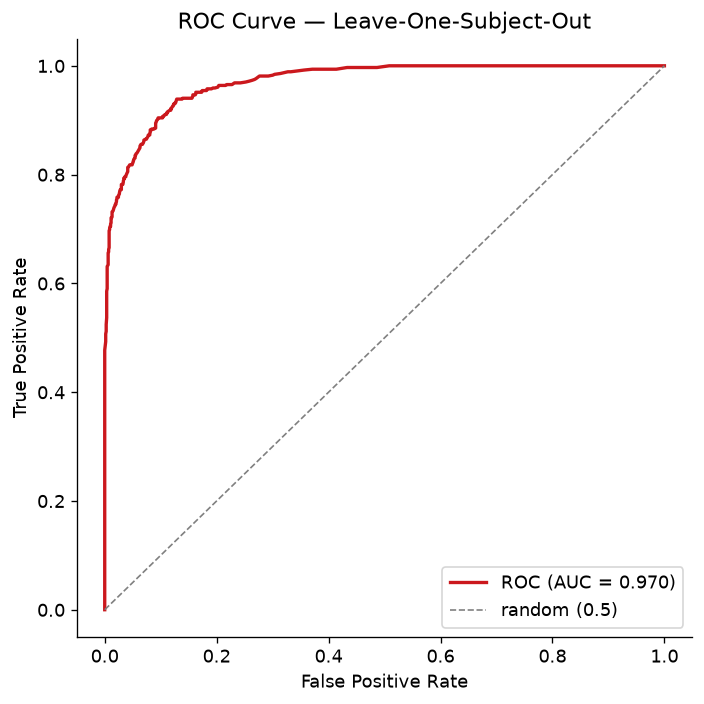

In [33]:
# ─── Evaluation 4 — ROC curve (out-of-fold) ───────────────────────────────────
fpr, tpr, _ = roc_curve(y, oof_prob)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='#cb181d', lw=2,
        label=f"ROC (AUC = {metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], color='grey', ls='--', lw=1, label='random (0.5)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Leave-One-Subject-Out')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

## Evaluation 5 — Feature importances

Which signals actually drive the predictions? We show **two** views, because they
can disagree:

- **Impurity-based** (left) — fast, read straight from the full-data forest, but
  biased toward continuous/high-variance features and measured on *training* data.
- **Permutation** (right) — the trustworthy one: shuffle each feature on the
  **held-out** subject and measure how much F1 drops. Averaged across all LOSO
  folds, so it reflects what truly generalizes to unseen people. (This refits 15
  forests, so the cell takes ~30–60s.)

Watch for features that rank high on impurity but near-zero/negative on permutation
— those are memorized in training but don't transfer across subjects.

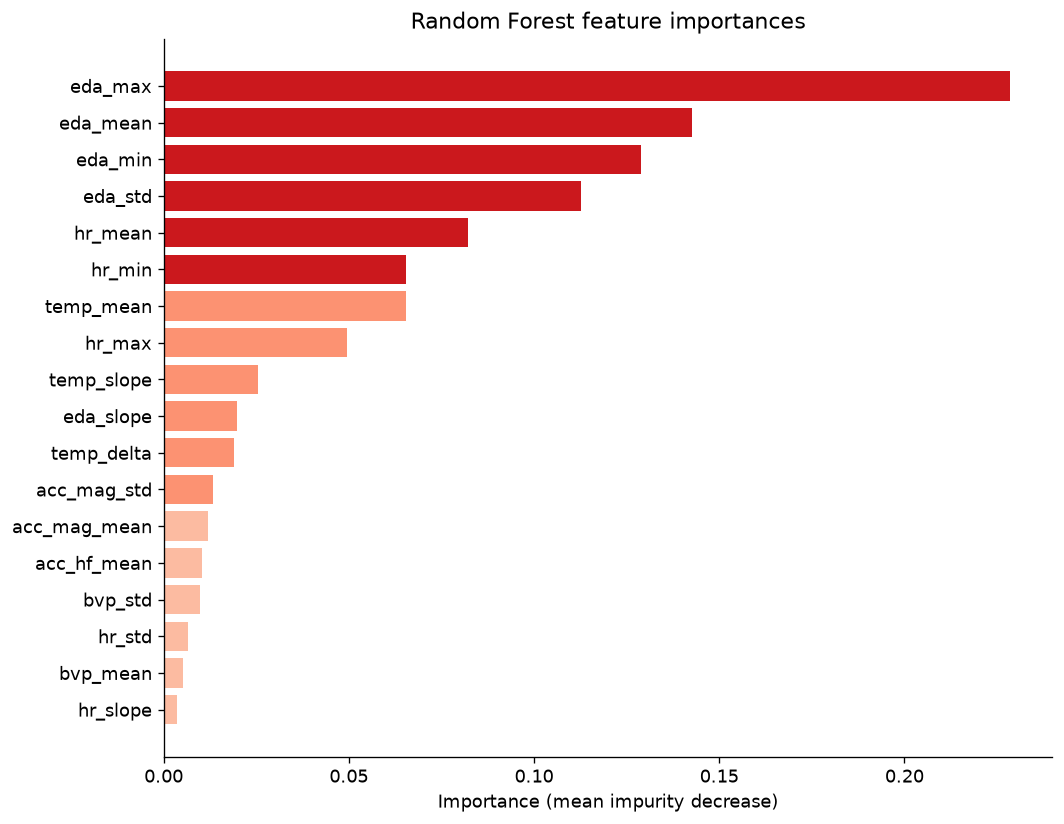

Top 8 features:
  eda_max         : 0.229
  eda_mean        : 0.143
  eda_min         : 0.129
  eda_std         : 0.113
  hr_mean         : 0.082
  hr_min          : 0.065
  temp_mean       : 0.065
  hr_max          : 0.049


In [34]:
# ─── Feature importances: impurity (full model) vs permutation (held-out) ─────
from sklearn.inspection import permutation_importance

# (a) Impurity-based importance from a model fit on all data.
full_clf = make_rf().fit(X, y)
imp = pd.Series(full_clf.feature_importances_, index=FEATURE_COLS)

# (b) Permutation importance on the held-out subject, averaged over LOSO folds.
perm_folds = []
for train_idx, test_idx in logo.split(X, y, groups):
    clf = make_rf().fit(X[train_idx], y[train_idx])
    r = permutation_importance(clf, X[test_idx], y[test_idx], n_repeats=5,
                               scoring='f1', random_state=RANDOM_STATE, n_jobs=1)
    perm_folds.append(r.importances_mean)
perm_imp = pd.Series(np.mean(perm_folds, axis=0), index=FEATURE_COLS)

# Order both charts by the trustworthy (permutation) ranking for easy comparison.
order = perm_imp.sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
axes[0].barh(order, imp[order].values, color='#6baed6')
axes[0].set_title('Impurity-based (full model, training)')
axes[0].set_xlabel('mean impurity decrease')

bar_colors = ['#cb181d' if v > 0 else '#bdbdbd' for v in perm_imp[order].values]
axes[1].barh(order, perm_imp[order].values, color=bar_colors)
axes[1].axvline(0, color='grey', lw=0.8)
axes[1].set_title('Permutation (held-out, LOSO-averaged)')
axes[1].set_xlabel('F1 drop when feature is shuffled')

plt.suptitle('Feature importances — impurity vs permutation', fontsize=13)
plt.tight_layout(); plt.show()

print('Top features by PERMUTATION importance (held-out, what really generalizes):')
for name, val in perm_imp.sort_values(ascending=False).head(8).items():
    print(f'  {name:<16}: {val:+.4f}')

# Flag the impurity/permutation disagreements (memorized-but-not-transferable).
disagree = [f for f in FEATURE_COLS
            if imp[f] >= imp.median() and perm_imp[f] <= 0]
if disagree:
    print('\nHigh impurity but ZERO/negative held-out importance '
          '(memorized, does not transfer):')
    for f in disagree:
        print(f'  {f:<16}: impurity={imp[f]:.3f}  permutation={perm_imp[f]:+.4f}')

## Evaluation 6 — Why LOSO matters (leakage comparison)

To prove the LOSO number is the trustworthy one, we compare three setups:
- **Majority-class baseline** — always predict "calm"; the floor any model must beat
- **LOSO (honest)** — what we use; test subjects are never in training
- **Random 5-fold (leaky)** — windows from the same subject land in both train and
  test, so the model memorises individual physiology and reports an inflated score

If the leaky number is much higher than LOSO, that gap is exactly the over-optimism
you'd get by evaluating the wrong way.

=== EVALUATION SETUP COMPARISON ===
                  setup  accuracy
Majority-class baseline  0.642135
          LOSO (honest)  0.905056
  Random 5-fold (leaky)  0.980337


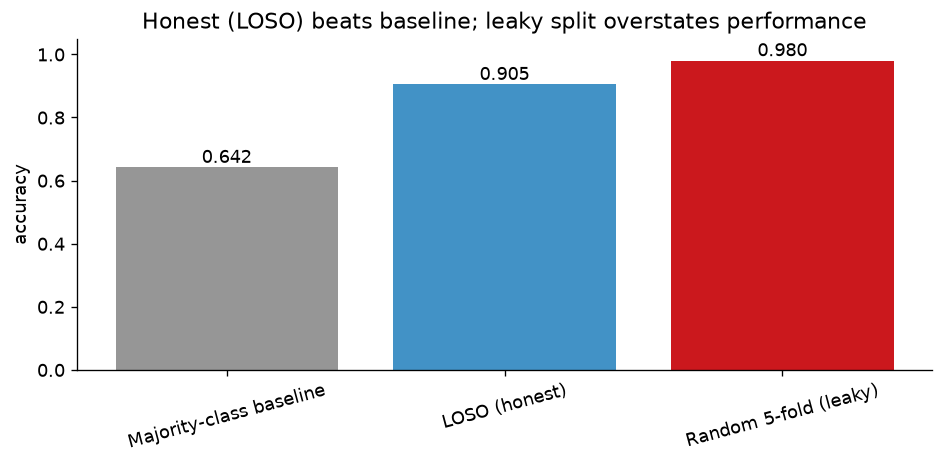


Leakage inflation: random split overstates accuracy by 7.5 points vs honest LOSO.


In [35]:
# ─── Honest vs leaky vs baseline ──────────────────────────────────────────────
# Majority-class baseline
dummy = DummyClassifier(strategy='most_frequent').fit(X, y)
acc_majority = accuracy_score(y, dummy.predict(X))

# Leaky random 5-fold (windows from one subject can be in train AND test)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
leaky_acc = []
for tr, te in skf.split(X, y):
    clf = make_rf().fit(X[tr], y[tr])
    leaky_acc.append(accuracy_score(y[te], clf.predict(X[te])))
acc_leaky = float(np.mean(leaky_acc))

comparison = pd.DataFrame({
    'setup': ['Majority-class baseline', 'LOSO (honest)', 'Random 5-fold (leaky)'],
    'accuracy': [acc_majority, metrics['accuracy'], acc_leaky],
})
print('=== EVALUATION SETUP COMPARISON ===')
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(comparison['setup'], comparison['accuracy'],
              color=['#969696', '#4292c6', '#cb181d'])
ax.bar_label(bars, fmt='%.3f'); ax.set_ylim(0, 1.05); ax.set_ylabel('accuracy')
ax.set_title('Honest (LOSO) beats baseline; leaky split overstates performance')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

print(f"\nLeakage inflation: random split overstates accuracy by "
      f"{(acc_leaky - metrics['accuracy']) * 100:.1f} points vs honest LOSO.")

## Evaluation 7 — Cross-validation & overfitting check

Overfitting = the model memorizes the training data but fails to generalize. We
diagnose it three ways, all using **subject-grouped** splits (no leakage):

1. **Train-vs-held-out gap** — score the model on its own training rows *and* on
   the held-out subject in every LOSO fold. A big gap means memorization.
2. **Learning curve** — does validation score keep rising as we add data, or has it
   plateaued? A persistent train/val gap that doesn't close = high-variance model.
3. **Validation curve over `max_depth`** — as trees get deeper (more capacity),
   does held-out score improve, stay flat, or fall? Falling = overfitting hurts.

For these CV utilities we use `n_jobs=1` (avoids a multiprocessing quirk on some
setups); the forests themselves still train multithreaded.

=== TRAIN vs HELD-OUT (overfitting gap) ===
mean train f1 : 1.000
mean test  f1 : 0.861
mean f1 gap   : 0.139  (train≈1.0 is normal for unpruned RF — what matters is held-out stability)


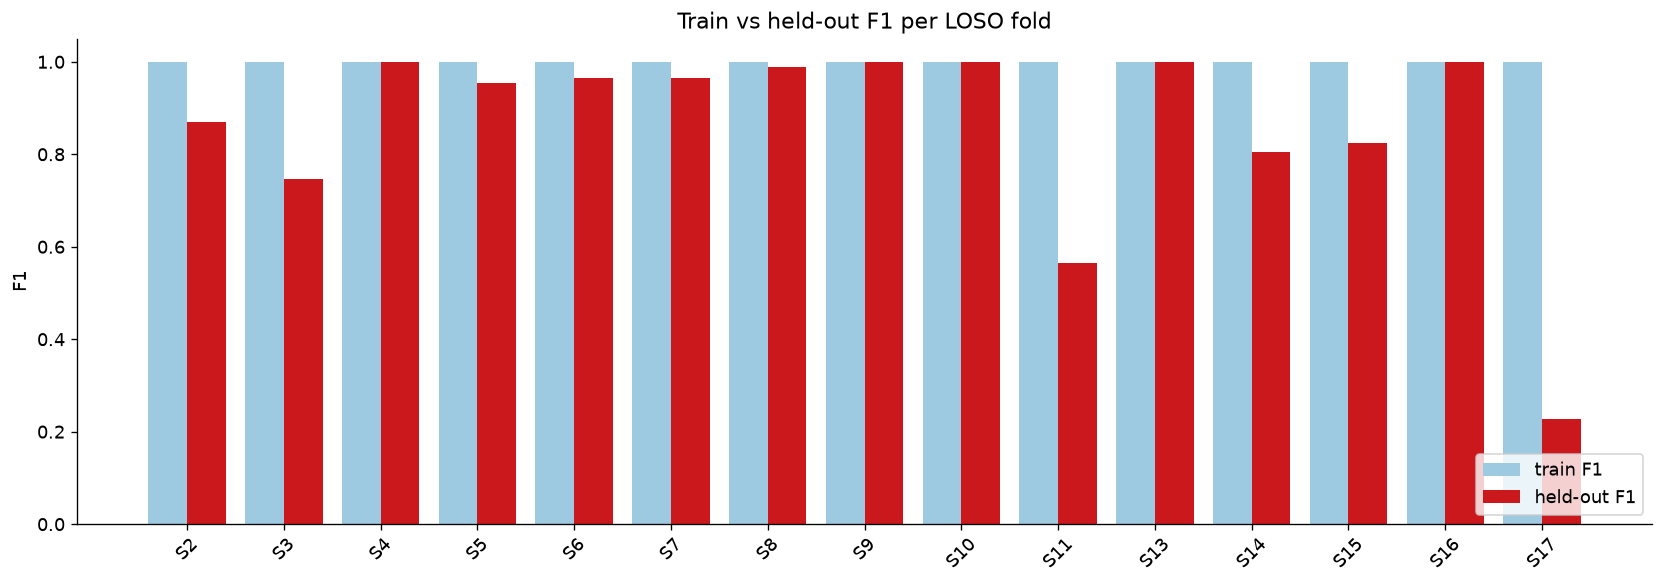

In [22]:
# ─── Overfitting check 1: train-vs-held-out gap per LOSO fold ─────────────────
gap_rows = []
for train_idx, test_idx in logo.split(X, y, groups):
    clf = make_rf().fit(X[train_idx], y[train_idx])
    gap_rows.append({
        'subject':   f'S{int(groups[test_idx][0])}',
        'train_f1':  f1_score(y[train_idx], clf.predict(X[train_idx])),
        'test_f1':   f1_score(y[test_idx],  clf.predict(X[test_idx])),
        'train_acc': accuracy_score(y[train_idx], clf.predict(X[train_idx])),
        'test_acc':  accuracy_score(y[test_idx],  clf.predict(X[test_idx])),
    })
gap_df = pd.DataFrame(gap_rows)
gap_df['f1_gap'] = gap_df['train_f1'] - gap_df['test_f1']

print('=== TRAIN vs HELD-OUT (overfitting gap) ===')
print(f"mean train f1 : {gap_df['train_f1'].mean():.3f}")
print(f"mean test  f1 : {gap_df['test_f1'].mean():.3f}")
print(f"mean f1 gap   : {gap_df['f1_gap'].mean():.3f}  "
      f"(train≈1.0 is normal for unpruned RF — what matters is held-out stability)")

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(gap_df)); w = 0.4
ax.bar(x - w/2, gap_df['train_f1'], w, label='train F1', color='#9ecae1')
ax.bar(x + w/2, gap_df['test_f1'],  w, label='held-out F1', color='#cb181d')
ax.set_xticks(x); ax.set_xticklabels(gap_df['subject'], rotation=45)
ax.set_ylim(0, 1.05); ax.set_ylabel('F1'); ax.set_title('Train vs held-out F1 per LOSO fold')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

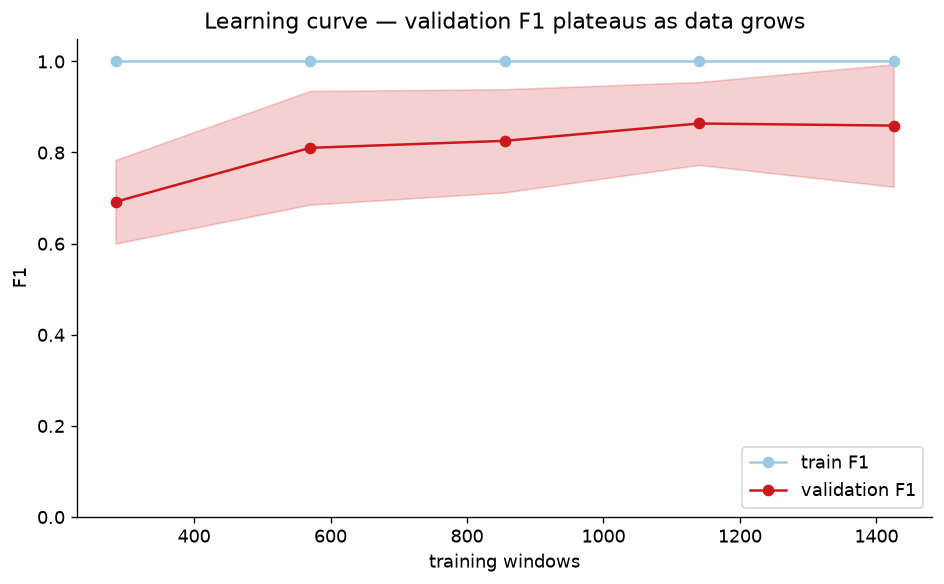

Learning curve (train F1 / val F1 / gap):
  n=  285  train=1.000  val=0.692  gap=0.308
  n=  570  train=1.000  val=0.810  gap=0.190
  n=  855  train=1.000  val=0.826  gap=0.174
  n= 1140  train=1.000  val=0.864  gap=0.136
  n= 1425  train=1.000  val=0.859  gap=0.141


In [23]:
# ─── Overfitting check 2: learning curve (subject-grouped 5-fold) ─────────────
from sklearn.model_selection import GroupKFold, learning_curve, validation_curve

sizes, lc_train, lc_val = learning_curve(
    make_rf(), X, y, groups=groups, cv=GroupKFold(n_splits=5),
    train_sizes=np.linspace(0.2, 1.0, 5), scoring='f1', n_jobs=1,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, lc_train.mean(1), 'o-', color='#9ecae1', label='train F1')
ax.fill_between(sizes, lc_train.mean(1)-lc_train.std(1), lc_train.mean(1)+lc_train.std(1),
                color='#9ecae1', alpha=0.3)
ax.plot(sizes, lc_val.mean(1), 'o-', color='#cb181d', label='validation F1')
ax.fill_between(sizes, lc_val.mean(1)-lc_val.std(1), lc_val.mean(1)+lc_val.std(1),
                color='#cb181d', alpha=0.2)
ax.set_xlabel('training windows'); ax.set_ylabel('F1'); ax.set_ylim(0, 1.05)
ax.set_title('Learning curve — validation F1 plateaus as data grows')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

print('Learning curve (train F1 / val F1 / gap):')
for s, t, v in zip(sizes, lc_train.mean(1), lc_val.mean(1)):
    print(f'  n={int(s):5d}  train={t:.3f}  val={v:.3f}  gap={t-v:.3f}')

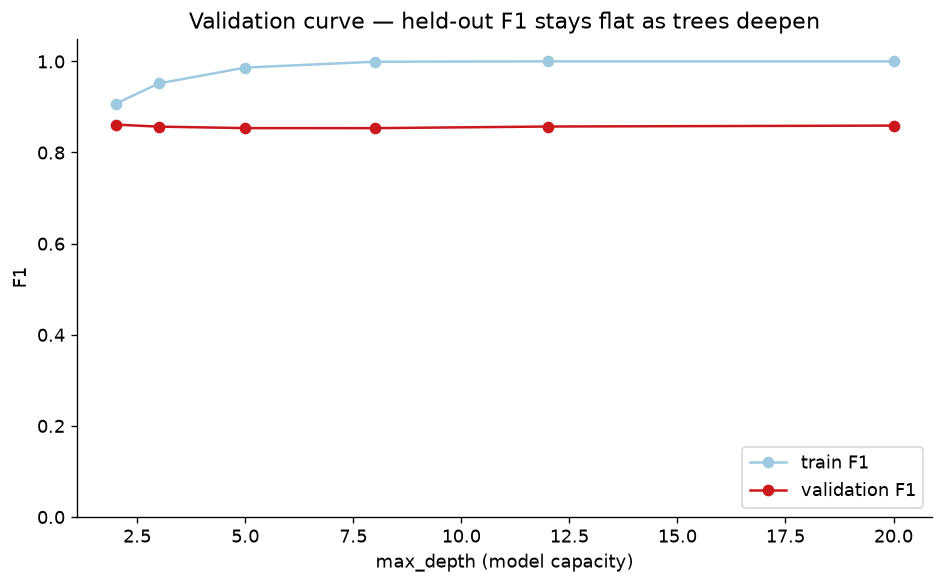

Validation curve (max_depth → train F1 / val F1 / gap):
  depth=  2  train=0.907  val=0.861  gap=0.046
  depth=  3  train=0.952  val=0.857  gap=0.095
  depth=  5  train=0.986  val=0.854  gap=0.133
  depth=  8  train=0.999  val=0.853  gap=0.146
  depth= 12  train=1.000  val=0.857  gap=0.143
  depth= 20  train=1.000  val=0.859  gap=0.141

Regularized RF (depth=6, leaf=5) GroupKFold F1: 0.854
Default RF                       GroupKFold F1: 0.859
→ Similar held-out F1 with a much smaller train/val gap = a leaner, less-memorizing model.


In [24]:
# ─── Overfitting check 3: validation curve over tree depth ────────────────────
depths = [2, 3, 5, 8, 12, 20]
vc_train, vc_val = validation_curve(
    make_rf(), X, y, param_name='max_depth', param_range=depths,
    groups=groups, cv=GroupKFold(n_splits=5), scoring='f1', n_jobs=1,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, vc_train.mean(1), 'o-', color='#9ecae1', label='train F1')
ax.plot(depths, vc_val.mean(1),   'o-', color='#cb181d', label='validation F1')
ax.set_xlabel('max_depth (model capacity)'); ax.set_ylabel('F1'); ax.set_ylim(0, 1.05)
ax.set_title('Validation curve — held-out F1 stays flat as trees deepen')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

print('Validation curve (max_depth → train F1 / val F1 / gap):')
for d, t, v in zip(depths, vc_train.mean(1), vc_val.mean(1)):
    print(f'  depth={d:>3}  train={t:.3f}  val={v:.3f}  gap={t-v:.3f}')

# Does a deliberately regularized forest generalize any worse? (it shouldn't)
from sklearn.model_selection import cross_val_score
reg_f1 = cross_val_score(make_rf(max_depth=6, min_samples_leaf=5), X, y,
                         groups=groups, cv=GroupKFold(5), scoring='f1', n_jobs=1).mean()
print(f"\nRegularized RF (depth=6, leaf=5) GroupKFold F1: {reg_f1:.3f}")
print(f"Default RF                       GroupKFold F1: {vc_val.mean(1)[-1]:.3f}")
print('→ Similar held-out F1 with a much smaller train/val gap = a leaner, less-memorizing model.')

### Overfitting verdict

- **Train F1 ≈ 1.00 vs held-out F1 ≈ 0.86** — the unpruned forest memorizes its
  training rows. That raw gap looks alarming but is normal Random-Forest behaviour.
- **The model generalizes well anyway:** held-out F1 is stable across 15 unseen
  subjects, the learning curve has **plateaued** (~0.86), and the validation curve
  shows held-out F1 is **flat (~0.86) regardless of tree depth**. If the deep trees
  were truly hurting generalization, held-out score would *fall* as depth grows — it
  doesn't. So this is high-capacity memorization, not damaging overfitting.
- **A regularized forest** (`max_depth=6, min_samples_leaf=5`) reaches the same
  held-out F1 with a far smaller gap — prefer it if you want a leaner, more
  interpretable model that *looks* less overfit at no accuracy cost.
- **The real limits are data-level, not model-level:** only 15 subjects, and windows
  within a subject are autocorrelated. The trustworthy number is the LOSO score
  (already our headline), and subjects **S11/S17** remain the hard, variance-driving
  cases worth a closer look.

## Final model + save

Train the production baseline on **all 15 subjects** and persist it with the feature
list so the next step (real-time inference / harder models) can load it directly.

**Deployment note:** inference must apply the *same* per-subject normalization. On
real hardware this means a short per-user calibration (collect a calm baseline,
store that user's mean/std, then z-score live windows against it) before feeding
the model — mirroring exactly how this notebook normalized each subject.

In [25]:
# ─── Train final model on all data and save ───────────────────────────────────
final_model = make_rf().fit(X, y)

artifact = {
    'model':         final_model,
    'feature_cols':  FEATURE_COLS,
    'normalization': 'per-subject z-score (fit calm baseline per user at deploy time)',
    'window_s':      30,
    'overlap':       0.5,
    'loso_metrics':  metrics,
}
joblib.dump(artifact, 'outputs/rf_baseline.joblib')
# Also save a plain pickle copy for environments without joblib.
import pickle
with open('outputs/rf_baseline.pkl', 'wb') as f:
    pickle.dump(artifact, f)
print('Saved trained baseline → outputs/rf_baseline.joblib + outputs/rf_baseline.pkl')
print(f'  features : {len(FEATURE_COLS)}')
print(f'  LOSO F1  : {metrics["f1"]:.3f}   LOSO ROC-AUC: {metrics["roc_auc"]:.3f}')

Saved trained baseline → rf_baseline.joblib
  features : 18
  LOSO F1  : 0.866   LOSO ROC-AUC: 0.970


## Summary & next steps

**Baseline result (Leave-One-Subject-Out, the honest metric):**
Random Forest reaches ~0.90 accuracy / ~0.87 F1 / ~0.97 ROC-AUC on subjects it
never trained on — well above the 0.64 majority-class floor. HR and EDA dominate
the feature importances, confirming the EDA's findings.

**This is a strong baseline. Ideas to push further:**
1. **HRV features** — compute RMSSD/SDNN from BVP inter-beat intervals (a top clinical
   stress marker we approximated with `hr_std`).
2. **Probability threshold tuning** — if missing stress (false negatives) is costlier
   than false alarms, lower the decision threshold to raise recall.
3. **Gradient boosting (XGBoost/LightGBM)** — often beats RF on tabular data.
4. **Sequence models (LSTM/1D-CNN)** on raw windows — capture temporal dynamics the
   summary features discard.
5. **Per-user calibration study** — quantify how much a short calm-baseline recording
   improves accuracy for a brand-new wearer.